### Hierarchical Multi-Agent Supervisor
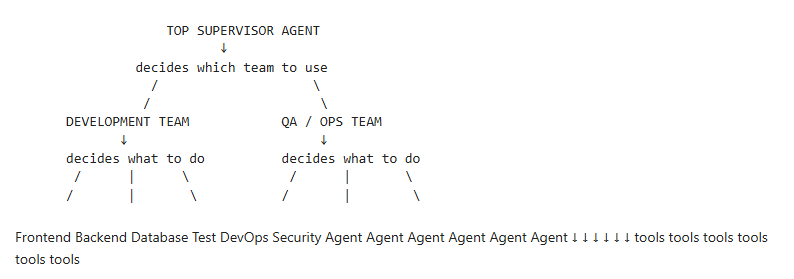

### development team

                        DEVELOPMENT TEAM LEAD
                         (decides strategy)
          ┌──────────────────────┼──────────────────────┐
          ▼                      ▼                      ▼
    FRONTEND AGENT         BACKEND AGENT          DATABASE AGENT
          ▼                      ▼                      ▼
     ┌──────────┐          ┌──────────┐          ┌──────────┐
     │ui        │          │api       │          │schema    │
     │components│          │logic     │          │migration │
     │styling   │          │routes    │          │queries   │
     │preview   │          │integrate │          │seed      │
     │testing   │          │validation│          │integrity │
     └──────────┘          └──────────┘          └──────────┘

### Qa team

                    QA / OPS TEAM LEAD
                     (decides strategy)
          ┌──────────────┼──────────────┐
          ▼              ▼              ▼
     TEST AGENT     DEVOPS AGENT   SECURITY AGENT
          ▼              ▼              ▼
     ┌────────┐    ┌──────────┐   ┌──────────┐
     │unit    │    │build     │   │sast      │
     │e2e     │    │cicd      │   │dast      │
     │visual  │    │iac/k8s   │   │secrets   │
     │coverage│    │observ.   │   │compliance│
     │reports │    │secrets   │   │incident  │
     └────────┘    └──────────┘   └──────────┘

In [1]:
# import
from typing import (
    TypedDict,
    Literal,
    Annotated,
)

import operator
import os
from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
)
from langchain_core.tools import tool
# from langchain.agents import create_agent

from langgraph.graph import (
    StateGraph,
    START,
    END,
    MessagesState,
)
from langgraph.graph.message import add_messages
from langgraph.types import (
    Command,
    Send,
)
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found - add it to your .env file.")

model = ChatOpenAI(
    model="nvidia/nemotron-3-ultra-550b-a55b:free",
    temperature=0,
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1",
    max_retries=3,   # free models hit 429 rate limits often
    timeout=120,
)

In [4]:
import json
import re


def reply_text(response, fallback="(no output)"):
    """Return the reply as a NON-EMPTY string (an empty one would make the supervisor loop)."""
    content = response.content
    if isinstance(content, list):
        content = "".join(b.get("text", "") if isinstance(b, dict) else str(b) for b in content)
    return (content or "").strip() or fallback


def parse_json_reply(response, default: dict) -> dict:
    """Extract the first {...} object from a reply (handles ```json fences / extra prose)."""
    match = re.search(r"\{.*\}", reply_text(response, ""), re.DOTALL)
    if match:
        try:
            data = json.loads(match.group(0))
            if isinstance(data, dict):
                return data
        except json.JSONDecodeError:
            pass
    return default

In [5]:
class TeamState(TypedDict):
    """State shared across the multi-agent team workflow.
    
    Attributes:
        task: The original task or prompt given to the team.
        dev_output: Aggregated output from development team.
        qa_output: Aggregated output from QA team.
        message: List of messages exchanged between agents
    """
    task: str
    dev_output: str
    qa_output: str
    message: Annotated[list, add_messages]

### Dev team in sequential workflow

In [6]:
# dev team
def dev_team(state: TeamState):
    """Developement agent team which takes the task and delegates the work to individual agents and aggregates their output."""

    all_agents = ["database", "backend", "frontend"]   # dependency order: schema -> API -> UI

    plan = f"""You are a Development Team Lead. Analyze the following task and decide which specialist agents are needed.

Task: {state['task']}

Available agents:
- frontend: UI components, styling, preview, testing
- backend: API logic, routes, integration, validation  
- database: Schema design, migrations, queries, seed data, integrity

Respond ONLY with a JSON object listing ONLY the agents needed:
{{
    "agents": ["frontend", "backend"],
    "reasoning": "Brief explanation of why each agent was selected"
}}"""

    # the lead decides (before: `plan` was built but never sent to the model)
    lead = model.invoke([HumanMessage(content=plan)])
    decision = parse_json_reply(lead, {"agents": all_agents})
    chosen = [a for a in all_agents if a in decision.get("agents", [])] or all_agents

    prompts = {
        "database": "You are a Database Developer. Implement the database for: {task}",
        "backend": "You are a Backend Developer. Implement the backend for: {task}",
        "frontend": "You are a Frontend Developer. Implement the frontend for: {task}",
    }

    # sequential: each agent sees what the previous ones produced
    outputs = {}
    for name in chosen:
        prompt = prompts[name].format(task=state["task"])
        if outputs:
            earlier = "\n\n".join(f"{k.title()} Output: {v}" for k, v in outputs.items())
            prompt += f"\n\nWork already done by teammates (build on it):\n{earlier}"
        outputs[name] = reply_text(model.invoke(prompt))      # .content, not the whole AIMessage

    return {
        "dev_output": "\n\n".join(f"{k.title()} Output: {v}" for k, v in outputs.items()),
    }

### Qa team in parallel

In [7]:
# QA / Ops Team Agents
def test_agent(state: TeamState):
    """Test agent handles unit, e2e, visual, coverage, reports."""
    prompt = f"""You are a Test Engineer. Review the development output: {state.get('dev_output', '')}
    Focus on: Unit tests, E2E tests, visual regression, coverage reports.
    Provide test strategy and specific test cases."""
    response = model.invoke([HumanMessage(content=prompt)])
    return {"message": [response]}

def devops_agent(state: TeamState):
    """DevOps agent handles build, CI/CD, IaC/K8s, observability, secrets."""
    prompt = f"""You are a DevOps Engineer. Review the development output: {state.get('dev_output', '')}
    Focus on: Build pipelines, CI/CD, Infrastructure as Code/K8s, observability, secrets management.
    Provide deployment and infrastructure strategy."""
    response = model.invoke([HumanMessage(content=prompt)])
    return {"message": [response]}

def security_agent(state: TeamState):
    """Security agent handles SAST, DAST, secrets scanning, compliance, incident response."""
    prompt = f"""You are a Security Engineer. Review the development output: {state.get('dev_output', '')}
    Focus on: SAST, DAST, secrets scanning, compliance, incident response.
    Provide security review and recommendations."""
    response = model.invoke([HumanMessage(content=prompt)])
    return {"message": [response]}


In [8]:
def qa_team(state: TeamState) -> Command[Literal["test_agent", "devops_agent", "security_agent"]]:
    """Coordinates the QA team by fanning out to test, devops, security agents."""
    dev_output = state.get('dev_output', '')
    payload = {"task": state["task"], "dev_output": dev_output, "message": []}
    return Command(goto=[
        Send("test_agent", payload),
        Send("devops_agent", payload),
        Send("security_agent", payload),
    ])

def aggregate_qa_outputs(state: TeamState):
    """Aggregate outputs from all QA agents."""
    messages = state.get('message', [])
    combined = "\n\n---\n\n".join([msg.content for msg in messages if isinstance(msg, AIMessage)])
    return {"qa_output": combined or "(no output)", "message": messages}   # never "" -> no endless loop

### supervisor node


In [9]:
def supervisor(state: TeamState) -> Command[Literal["dev_team", "qa_team", END]]:
    """
    Hierarchical supervisor that routes between Development Team and QA Team.
    First runs dev team, then QA team, then ends.
    """
    if not state.get('dev_output'):
        # First pass: run development team
        return Command(goto="dev_team")
    elif not state.get('qa_output'):
        # Second pass: run QA team with dev output
        return Command(goto="qa_team")
    else:
        # Both teams complete
        return Command(goto=END)

Graph compiled successfully!


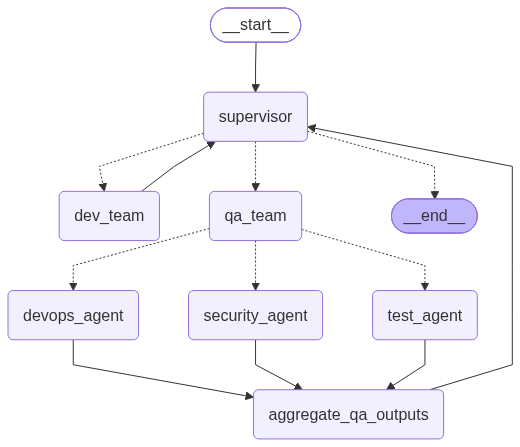

In [10]:
# Build the Hierarchical Multi-Agent Graph
builder = StateGraph(TeamState)

# Add supervisor node
builder.add_node("supervisor", supervisor)

# Development Team nodes
builder.add_node("dev_team", dev_team)


# QA Team nodes
builder.add_node("qa_team", qa_team)
builder.add_node("test_agent", test_agent)
builder.add_node("devops_agent", devops_agent)
builder.add_node("security_agent", security_agent)
builder.add_node("aggregate_qa_outputs", aggregate_qa_outputs)

# Edges: START -> Supervisor
builder.add_edge(START, "supervisor")

# Dev Team (sequential, inside the node): when done, report back to the supervisor
builder.add_edge("dev_team", "supervisor")

# QA Team (parallel): qa_team fans out via Send; aggregate waits for ALL three agents
builder.add_edge(["test_agent", "devops_agent", "security_agent"], "aggregate_qa_outputs")
builder.add_edge("aggregate_qa_outputs", "supervisor")

# Compile with memory
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# Visualize the graph
print("Graph compiled successfully!")
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("\nMermaid diagram:")
    print(graph.get_graph().draw_mermaid())

In [11]:
# Test the Hierarchical Multi-Agent System
if __name__ == "__main__":
    # Sample task
    task = "Build a user authentication system with login, registration, and password reset functionality"
    
    # Initial state
    initial_state = {
        "task": task,
        "dev_output": "",
        "qa_output": "",
        "message": []
    }
    
    # Run the graph
    config = {"configurable": {"thread_id": "test-1"}, "recursion_limit": 15}
    result = graph.invoke(initial_state, config=config)
    
    print("=" * 60)
    print("DEVELOPMENT TEAM OUTPUT")
    print("=" * 60)
    print(result.get('dev_output', 'No output'))
    
    print("\n" + "=" * 60)
    print("QA / OPS TEAM OUTPUT")
    print("=" * 60)
    print(result.get('qa_output', 'No output'))

DEVELOPMENT TEAM OUTPUT
Database Output: Here is a production-ready database implementation for a User Authentication System.

**Stack:** **PostgreSQL** (Industry standard for relational auth systems). Syntax is easily adaptable to MySQL/SQL Server.
**Security Baseline:** Argon2id hashing (via `pgcrypto` or application layer), Constant-time comparison, Short-lived tokens, Rate limiting hooks.

---

### 1. Schema Design (DDL)

```sql
-- Enable required extensions
CREATE EXTENSION IF NOT EXISTS "pgcrypto";      -- For gen_random_uuid, crypt (if doing DB-level hash)
CREATE EXTENSION IF NOT EXISTS "uuid-ossp";     -- Alternative UUID generator

-- ==========================================
-- CORE USERS TABLE
-- ==========================================
CREATE TABLE users (
    id              UUID PRIMARY KEY DEFAULT gen_random_uuid(),
    email           VARCHAR(320) NOT NULL UNIQUE, -- RFC 5321 max length
    email_verified  BOOLEAN NOT NULL DEFAULT FALSE,
    username        VARCHAR(5